---
# **Lab: PyTorch learning**
---

# ▶️ CUDA tools...

In [ ]:
!nvidia-smi

# ✅ Non linear regression

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import numpy as np
from utils import *

# Define the function
def fun(x):
    return x**3 - 2.5 * x**2 + 25 * np.sin(2 * x)

In [2]:
fig = go.Figure()

plot the function...

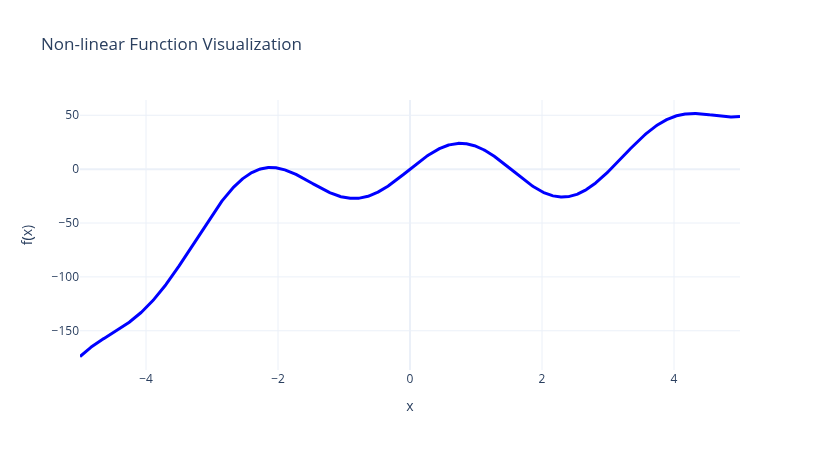

In [3]:
# Create input and output
x_true = np.linspace(start=-5, stop=5, num=1000)
y_true = fun(x_true)

# plot
plot_fun(x=x_true, y=y_true)

Generate noisy data...

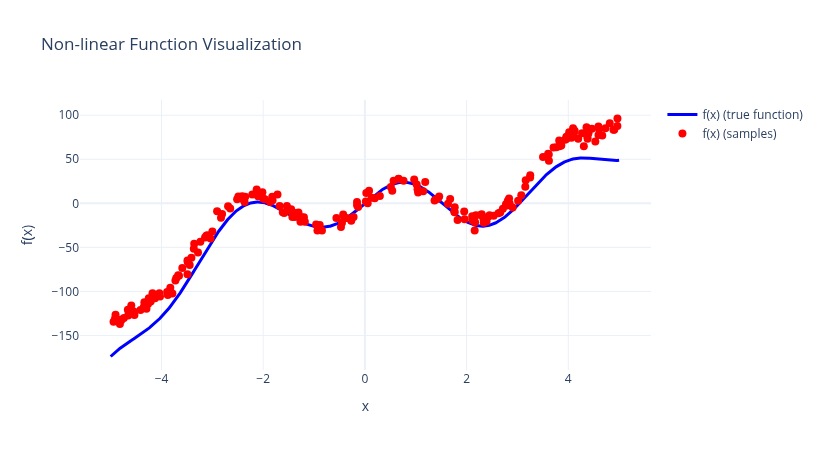

In [5]:
# generate data with noise

n = 200 # number of observations

# get noise around y observations
yNormal = torch.distributions.Normal(loc=0.0, scale=5)
yNoise  = yNormal.sample([n])

# get observations
x = 10*torch.rand([n])-5    # uniform from [-5,5]
y = x**3 - x**2 + 25 * torch.sin(2*x) + yNoise

# Scatter plot of x vs y using Plotly
plot_fun(x=x_true, y=y_true, x_scatter=x.numpy(), y_scatter=y.numpy())

In [6]:
class NonLinearRegressionData(Dataset):
    '''
    Custom 'Dataset' object for our regression data.
    Must implement these functions: __init__, __len__, and __getitem__.
    '''

    def __init__(self, xObs, yObs):
        self.xObs = torch.reshape(xObs, (len(xObs), 1))
        self.yObs = torch.reshape(yObs, (len(yObs), 1))

    def __len__(self):
        return len(self.xObs)

    def __getitem__(self, idx):
        return self.xObs[idx], self.yObs[idx]

# instantiate Dataset object for current training data
d = NonLinearRegressionData(x, y)

# instantiate DataLoader
#    we use the B batches of 25 observations each (full data  has 100 observations)
#    we also shuffle the data
train_dataloader = DataLoader(d, batch_size=25 , shuffle=True)

Define the model...

In [7]:
# net params

nInput  = 1
nHidden = 10
nOutput = 1

# net model: MLP
class MLP(nn.Module):
    '''
    Multi-layer perceptron for non-linear regression.
    '''
    def __init__(self, nInput, nHidden, nOutput):
        super(MLP, self).__init__()
        self.nInput  = nInput
        self.nHidden = nHidden
        self.nOutput = nOutput
        self.linear1 = nn.Linear(self.nInput, self.nHidden)
        self.linear2 = nn.Linear(self.nHidden, self.nHidden)
        self.linear3 = nn.Linear(self.nHidden, self.nHidden)
        self.linear4 = nn.Linear(self.nHidden, self.nOutput)
        self.ReLU    = nn.ReLU()

    def forward(self, x):
        h1 = self.ReLU(self.linear1(x))
        h2 = self.ReLU(self.linear2(h1))
        h3 = self.ReLU(self.linear3(h2))
        output = self.linear4(h3)
        return output

In [8]:
# model definition and print
model = MLP(nInput, nHidden, nOutput)
model

MLP(
  (linear1): Linear(in_features=1, out_features=10, bias=True)
  (linear2): Linear(in_features=10, out_features=10, bias=True)
  (linear3): Linear(in_features=10, out_features=10, bias=True)
  (linear4): Linear(in_features=10, out_features=1, bias=True)
  (ReLU): ReLU()
)

In [9]:
# loss function
loss_fn = nn.MSELoss()

# num n_epochs
n_epochs = 10000

## training the model
train_MLP(model, n_epochs, train_dataloader, loss_fn)

Loss after epoch  1000: 6565.280
Loss after epoch  2000: 5420.729
Loss after epoch  3000: 3674.182
Loss after epoch  4000: 1607.166
Loss after epoch  5000: 855.565
Loss after epoch  6000: 451.621
Loss after epoch  7000: 317.728
Loss after epoch  8000: 296.679
Loss after epoch  9000: 290.067
Loss after epoch 10000: 286.901
Training process has finished.


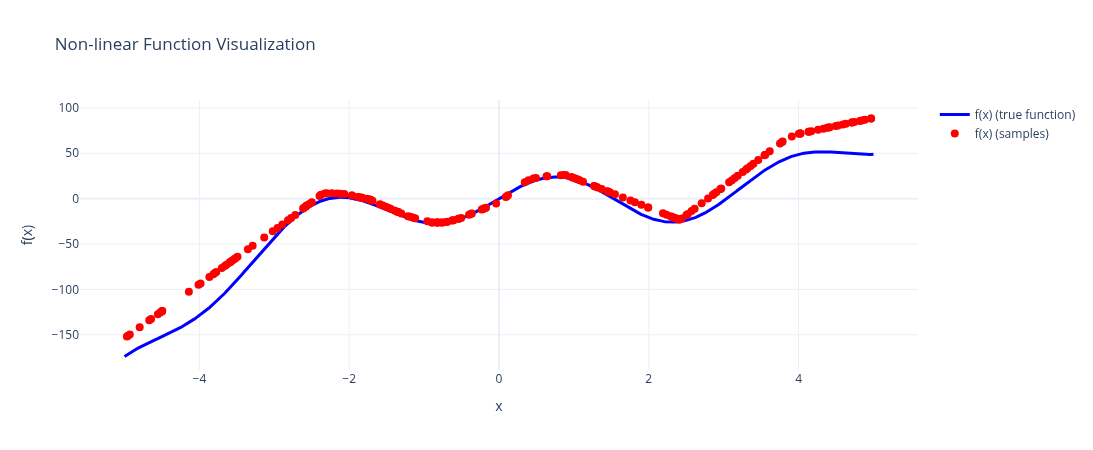

In [10]:
# prediction of the model

y_pred = model(x.unsqueeze(1)).squeeze()
x1 = x.detach().numpy()
y1 = y_pred.detach().numpy()

plot_fun(x=x_true, y=y_true, x_scatter=x1, y_scatter=y1)

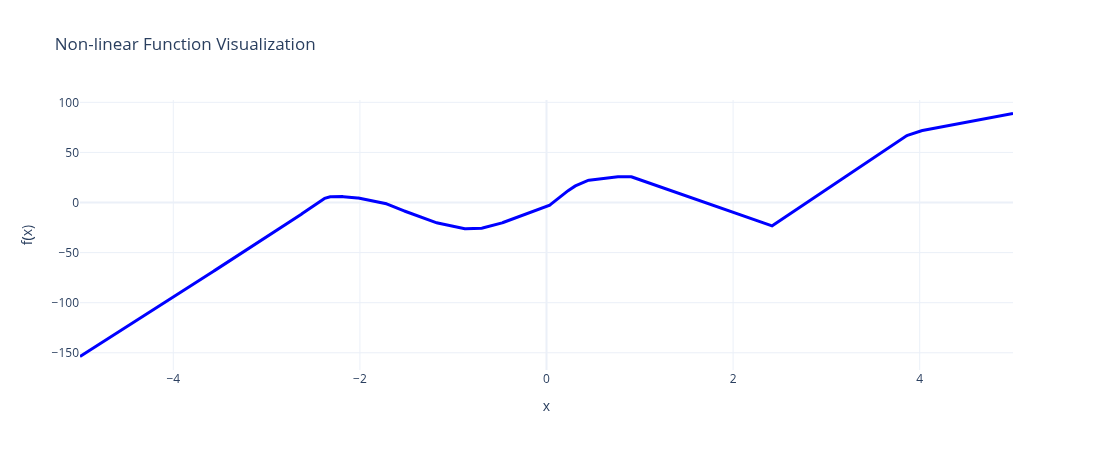

In [11]:
x_torch = torch.linspace(start=-5, end=5, steps=1000, dtype=torch.float32).unsqueeze(1) # becomes 2D = (B x 1)
y_torch = model(x_torch)

x1 = x_torch.detach().numpy().squeeze()
y1 = y_torch.detach().numpy().squeeze()
plot_fun(x=x1, y=y1)

In [ ]:
#torch.onnx.export(model, x_torch, 'model_regression.onnx', input_names=["features"], output_names=["logits"])

## ↘️ TODO...

🔹 **Base reference model**

You are given the following baseline architecture:

```python
MLP(1 → 10 → 10 → 10 → 1)
```

- with:
	-	ReLU activations
	-	MSE loss
	-	Learning rate $10^{-4}$

- This will be your control model

🔹 **Depth study (shallow vs deep)**

- Train the following models:

```
Model	Architecture
D1	1 → 10 → 1
D2	1 → 10 → 10 → 1
D3	1 → 10 → 10 → 10 → 1 (baseline)
D4	1 → 10 → 10 → 10 → 10 → 1
```

- Tasks
	1.	Plot training loss vs epochs for each model.
	2.	Plot final predictions vs ground truth.
	3.	Count total trainable parameters.
	
🔹 **Width study (narrow vs wide)**

- Fix depth to 3 hidden layers and vary width:

```
Model	Architecture
W1	1 → 5 → 5 → 5 → 1
W2	1 → 10 → 10 → 10 → 1
W3	1 → 50 → 50 → 50 → 1
W4	1 → 100 → 100 → 100 → 1
```

- Tasks
	1.	Compare convergence speed
	2.	Compare final error
	3.	Analyze overfitting risk

🔹 **Activation function study**

- Using the baseline architecture, replace ReLU with:

|Activation	|PyTorch|
|---|---|
|ReLU 	|nn.ReLU()|
|Tanh	|nn.Tanh()|
|Sigmoid|	nn.GeLU()|
|Softplus|	nn.Softplus()|
|None	|no activation|

- Tasks
	1.	Train each model
	2.	Plot loss curves
	
🔹 **Linear vs non-linear expressivity**
	
1.	Train a fully linear model:
```
Linear → Linear → Linear → Linear
```

2.	Compare against the ReLU model


## ➡️ Solution...

In [7]:
# net params

nInput  = 1
nHidden = [10, 20, 10]
nOutput = 1

# new model
class MLP(nn.Module):

    def __init__(self, nInput, nHidden, nOutput):
        super(MLP, self).__init__()
        self.layers = nn.Sequential()
        self.layers.append(nn.Linear(nInput, nHidden[0]));
        for i in range(len(nHidden) - 1):
            self.layers.append(nn.Linear(nHidden[i], nHidden[i+1]))
        self.layers.append(nn.Linear(nHidden[-1], nOutput))

    def forward(self, x):
        self.layers(x)

In [11]:
# model definition and print
model = MLP(nInput, nHidden, nOutput)
model

MLP(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=10, bias=True)
    (1): Linear(in_features=10, out_features=20, bias=True)
    (2): Linear(in_features=20, out_features=10, bias=True)
    (3): Linear(in_features=10, out_features=1, bias=True)
  )
)

In [12]:
# loss function
loss_fn = nn.MSELoss()

# num n_epochs
n_epochs = 10000

## training the model
train_MLP(model, n_epochs, train_dataloader, loss_fn)

AttributeError: 'NoneType' object has no attribute 'size'

In [10]:
# prdiction of the model

y_pred = model(x.unsqueeze(1)).squeeze()
x2 = x.detach().numpy()
y2 = y_pred.detach().numpy()
plot_fun(x=x_true, y=y_true ,x_scatter=x2, y_scatter=y2)

AttributeError: 'NoneType' object has no attribute 'squeeze'

# ✅ Classification problem

## Architecture cheat sheet

| Hyperparameter | Binary Classification | Multiclass Classification |
|---|---|---|
| Input layer shape (`in_features`) | Same as # features | Same as binary |
| Hidden layer(s) | Problem specific (min 1, max unlimited) | Same as binary |
| Neurons per hidden layer | Problem specific (often 10–512) | Same as binary |
| Output layer shape (`out_features`) | 1 | 1 per class |
| Hidden activation | Usually ReLU | Same as binary |
| Output activation | Sigmoid (`torch.sigmoid`) | Softmax (`torch.softmax`) |
| Loss function | BCE (`nn.BCEWithLogitsLoss` / `nn.BCELoss`) | CE (`nn.CrossEntropyLoss`) |
| Optimizer | SGD, Adam, etc. | Same as binary |

**Make classification data and get it ready**

We’ll create a toy binary classification dataset using `make_circles()` from Scikit-Learn.

Create circles data...

In [ ]:
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples = 2000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

Inspect samples...

In [ ]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

Visualize with a DataFrame...

In [ ]:
import pandas as pd

circles = pd.DataFrame({
  "X1": X[:, 0],
  "X2": X[:, 1],
  "label": y
})

circles.head(10)

Check label balance...

In [ ]:
circles.label.value_counts()

Plot the circles...

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(x=X[:, 0], y=X[:, 1], c=y, cmap=plt.cm.RdYlBu);

Check shapes...

In [ ]:
X.shape, y.shape

Inspect one sample...

In [ ]:
X_sample = X[0]
y_sample = y[0]

print(f"Values for one sample of X: {X_sample} and y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and y: {type(y_sample)}")

**Convert to tensors + train/test split**

PyTorch prefers working with `torch.Tensor`.

We’ll also split:
- 80% train
- 20% test

Convert NumPy → Torch tensors...

In [ ]:
import torch
import torch.nn as nn

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

Train/test split...

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

len(X_train), len(X_test), len(y_train), len(y_test)

Building a model...

- define a model with `nn.Module`
- train with a classification-specific loop

Define a simple binary classifier (V0)...

In [ ]:
class model_circle0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=5)
        self.layer_2 = nn.Linear(in_features=5, out_features=1)

    def forward(self, x):
        return self.layer_2(self.layer_1(x))

model0 = model_circle0()
model0

Untrained predictions...

In [ ]:
untrained_preds = model0(X_test)
print(f"Preds shape: {untrained_preds.shape}")
print(f"Labels shape: {y_test.shape}")

print(untrained_preds[:10])
print(y_test[:10])

**Loss function**

Binary classification typically uses **binary cross entropy**.

Prefer:

- `nn.BCEWithLogitsLoss()` (includes sigmoid internally)

Setup loss and optimizer...

In [ ]:
loss_fn = nn.BCEWithLogitsLoss()

**Train model**

- **Logits → probs → labels**

- Model outputs are **logits**.

- Binary classification:

    - logits $\rightarrow$ sigmoid $\rightarrow$ probabilities  
    - probabilities $\rightarrow$ round $\rightarrow$ class labels

Convert logits...

In [ ]:
y_logits = model0(X_test)[:5]
y_pred_probs = torch.sigmoid(y_logits)
y_preds = torch.round(y_pred_probs)

y_logits, y_pred_probs, y_preds

Training + testing loop (100 epochs)...

In [ ]:
from utils11 import train_model, accuracy_fn

# params
torch.manual_seed(42)
epochs = 2000

# train the model
train_model(model0, epochs, X_train, X_test, y_train, y_test, loss_fn)

# test model
test_logits = model0(X_test).squeeze()
test_pred = torch.round(torch.sigmoid(test_logits))
test_loss = loss_fn(test_logits, y_test)
test_acc = accuracy_fn(y_test, test_pred)
print(f"\nTest: Loss {test_loss:.4f}, accuracy {test_acc:.2f}%")
         

**Observation: underfitting**

- If accuracy hovers near **50%** on balanced data, the model is close to random guessing
- For circles, a purely linear model tends to draw a **straight decision boundary**

Plot decision boundary...

In [ ]:
from utils import plot_decision_boundary

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model0, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model0, X_test, y_test)

## ↘️ TODO...

**Improving a model (model-side)**

Common hyperparameter tweaks:

- add more layers (deeper)
- add more hidden units (wider)
- train longer (more epochs)
- change activation functions (introduce non-linearity)
- choose a suitable loss

## ➡️ Solution...

In [ ]:
class model_circle1(nn.Module):
    # TODO
    pass

Training + testing loop (100 epochs)...

In [ ]:
from utils import train_model, accuracy_fn

# params
torch.manual_seed(42)
epochs = 2000

# train the model
train_model(model1, epochs, X_train, X_test, y_train, y_test, loss_fn)

# test model
test_logits = model1(X_test).squeeze()
test_pred = torch.round(torch.sigmoid(test_logits))
test_loss = loss_fn(test_logits, y_test)
test_acc = accuracy_fn(y_test, test_pred)
print(f"\nTest: Loss {test_loss:.4f}, accuracy {test_acc:.2f}%")
         

Plot improved decision boundary...

In [ ]:
from helper_functions import plot_decision_boundary

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model1, X_train, y_train)  # no non-linearity

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model1, X_test, y_test)    # with ReLU

## ↘️ TODO...

🔹 **Part 1 — Create the dataset**

1.  Use `sklearn.datasets.make_blobs()` to generate a dataset with:
    -   `n_samples = 1000`
    -   `n_features = 2`
    -   `centers = 4`
    -   `cluster_std = 1.5`
    -   `random_state = 42`
2.  Convert the data to PyTorch tensors:
    -   Features: `torch.float`
    -   Labels: `torch.long`
3.  Split the dataset into:
    -   **80% training**
    -   **20% testing**
4.  Visualize the dataset using `matplotlib`.


🔹 **Part 2 — Build the model**

- Subclass `nn.Module` to create a model that:
    -   Accepts `input_features=2`
    -   Outputs `output_features=4`
    -   Uses at least **two hidden layers**
    -   Includes **non-linear activation functions** (e.g. `ReLU`)

💡 *Hint:* Start with 8–32 hidden units per layer


🔹 **Part 3 — Loss function and optimizer**

- Use a loss function suitable for multi-class classification: `nn.CrossEntropyLoss`


🔹 **Part 4 — Training loop**

1.  Train the model for **at least 100 epochs**

2.  Convert logits to predictions using: 
    ```{python}
    python y_pred = torch.softmax(logits, dim=1).argmax(dim=1)\
    ```

3.  Track and print:

    -   Training loss
    -   Training accuracy
    -   Test loss
    -   Test accuracy (every 10 epochs)


🔹 **Part 5 — Evaluation**

1. Evaluate the trained model on the test set

2. Ensure your final test accuracy ≥ 95%.

3. Visualize the decision boundaries using:

plot_decision_boundary(model, X_test, y_test)


🔹 **Part 6 — Analysis questions**

1. Why does `nn.CrossEntropyLoss` not require a softmax layer inside the model?

2. What happens if you remove all non-linear activation functions?

3. How does changing cluster_std affect the difficulty of the task?

🔹 **Expected outcome**
     
-   Build a multi-class PyTorch model
-   Correctly use CrossEntropyLoss
-   Convert logits → probabilities → class predictions
-   Visualize decision boundaries
-   Diagnose underfitting vs. overfitting in multi-class settings


Create multi-class data with `make_blobs`...

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob, y_blob = make_blobs(
    n_samples=1000,
    n_features=NUM_FEATURES,
    centers=NUM_CLASSES,
    cluster_std=1.5,
    random_state=RANDOM_SEED
)

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(
    X_blob, y_blob, test_size=0.2, random_state=RANDOM_SEED
)

plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu);

Build a multi-class model...

In [ ]:
from torch import nn

class BlobModel(nn.Module):
    # TODO
    pass

Loss + optimizer for multi-class...

In [ ]:
# TODO

Logits → probs → labels (softmax)...    

In [ ]:
# TODO

Train loop (100 epochs)...

In [ ]:
torch.manual_seed(42)
epochs = 100

X_blob_train, y_blob_train = X_blob_train, y_blob_train
X_blob_test, y_blob_test = X_blob_test, y_blob_test

# train the model
train_model(model, epochs, X_blob_train, X_blob_test, y_blob_train, y_blob_test, loss_fn)

# TEST data

Visualize decision boundary (multi-class)... 

In [ ]:
# TODO

**More classification metrics**

Beyond accuracy, consider:

- Precision
- Recall
- F1-score
- Confusion matrix
- Classification report

Libraries:
- Scikit-Learn metrics
- TorchMetrics